# Práctica 04 (5%) Entrega Lección 07, 17:30 horas

1. Explore las distribuciones de algunos atributos (columnas) del data set de su proyecto grupal. (Coordinen entre los integrantes del grupo para que seleccionen atributos distintos). Utilice tablas de frecuencias, resúmenes numéricos, histogramas y "boxplots" para describir el comportamiento de los datos del atributo y comparaciones con las distribuciones de otros atributos. Si es el caso puede crear etiquetas para categorías (como en el caso de género, nivel educativo o la mediana del ingreso de los ejemplos vistos en clase).
  
2. A partir del data set de su proyecto genere un training set y un test set de forma aleatoria (80% training y 20% test).  Luego escoja un atributo cuya distribución ustede piense que deba ser considerada en la construcción de los data sets y genere dos nuevos sets (igual 80% y 20%) y compárelos. (Como se hizo en clase). Igual que en el punto 1 coordinen entre los integrantes del grupo para seleccionar atributos distintos.


0
risklevel
Moderate     32
High         31
Low          10
Very High     3
Name: count, dtype: int64
count         76
unique         4
top       stable
freq          39
Name: salarytrend, dtype: object


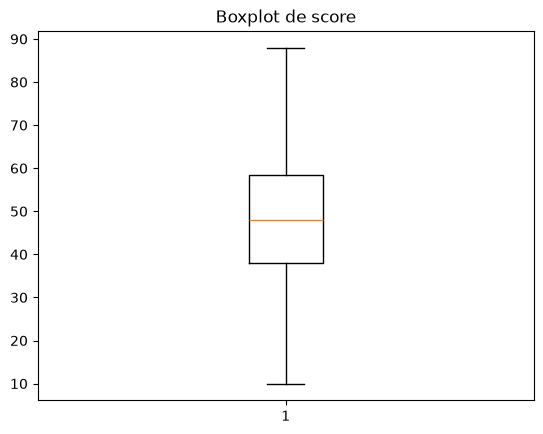

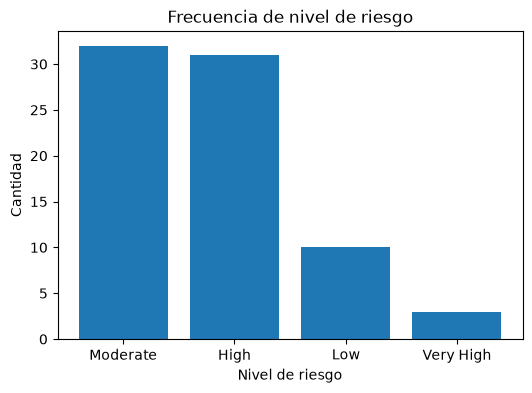

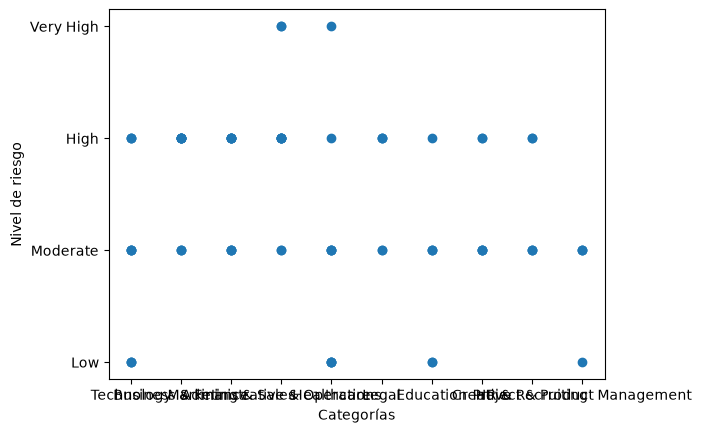

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import json
import urllib.request
from collections.abc import Hashable

# Leer datos de URL
source = "https://www.meritforgeai.com/data/ai-career-threat-index.json"

# Llenar data con la respuesta 
with urllib.request.urlopen(source) as response:
    data = json.load(response)

# Ya que el dataset está nested, se lee desde la parte importante
df = pd.json_normalize(data["roles"])

df.head()

def get_hashable_columns(df):
    hashable_cols = []

    for col in df.columns:
        # Ignorar columnas vacías
        if df[col].dropna().map(lambda x: isinstance(x, Hashable)).all():
                hashable_cols.append(col)

    return hashable_cols

def limpiar_df(df):

    # Limpiar
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    hashable_cols = get_hashable_columns(df)
    print(df.duplicated(subset=hashable_cols).sum())

    # Eliminamos filas duplicadas

    clean_df = df.drop_duplicates(subset=hashable_cols).copy()

    clean_df.dropna(axis='columns', how='all', inplace=True)  # Elimina columnas que son completamente nulas
    clean_df.dropna(axis='index', how='all', inplace=True) # Elimina filas que son completamente nulas
    clean_df = clean_df.infer_objects() # Inferir tipos de daots automáticamente

    for column in clean_df.columns:
                if pd.api.types.is_numeric_dtype(clean_df[column]):
                    clean_df[column] = clean_df[column].fillna(clean_df[column].median())
                else:
                    clean_df[column] = clean_df[column].fillna("Desconocido")

    return clean_df

clean_df = limpiar_df(df)
    
# Frencuencias

print(clean_df["risklevel"].value_counts())


# Resúmenes numéricos

print(clean_df["salarytrend"].describe())

# Boxplot
plt.boxplot(clean_df["score"])
plt.title("Boxplot de score")
plt.show()


# Barras
risk_counts = clean_df["risklevel"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(risk_counts.index, risk_counts.values)
plt.title("Frecuencia de nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad")
plt.show()

# Scatter
plt.scatter(clean_df["category"], clean_df["risklevel"])
plt.xlabel("Categorías")
plt.ylabel("Nivel de riesgo")
plt.show()